In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
import sys
import os
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', ''))
sys.path.append(src_path)
# model
from src.models.BERTRegressionModel import RegressionModel
from src.models.BERTRegressionModelDropout import RegressionModelDropout
from src.models.SiameseScoringModel import SiameseScoringModel
from src.models.SiameseModel import SiameseModel
# dataset
from src.datasets.BERTDataset import AutomaticScoringDataset
from src.datasets.SBERTDataset import SBERTDataset
from transformers import BertTokenizer, AutoTokenizer, AutoModel
# evaluation
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# df = pd.read_csv("../data/aes_dataset_5k_clean.csv")
# df = df[df['dataset_num'] == 'analisis_essay-1']
# df = df[df['dataset'] == 'analisis_essay'][['question', 'reference_answer', 'answer', 'score']]
# print(df.info())
# df.head()
# print(df['question'].iloc[0])
# df['reference_answer'].iloc[0]

In [3]:
# pd.set_option('display.max_colwidth', None)
# df[['answer', 'score']].sort_values(by='score').style.set_properties(**{'text-align': 'left'})

In [4]:
df = pd.read_csv("../data/aes_dataset_5k_clean.csv")
df = df[df['dataset'] == 'analisis_essay'][['reference_answer', 'answer', 'score', 'normalized_score', 'dataset', 'dataset_num']]
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2162 entries, 0 to 2161
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   reference_answer  2162 non-null   object 
 1   answer            2162 non-null   object 
 2   score             2162 non-null   float64
 3   normalized_score  2162 non-null   float64
 4   dataset           2162 non-null   object 
 5   dataset_num       2162 non-null   object 
dtypes: float64(2), object(4)
memory usage: 118.2+ KB
None


,reference_answer,answer,score,normalized_score,dataset,dataset_num
0,Fungsi karbohidrat adalah sebagai pemasok ener...,"sumber tenaga, pemanis alami, menjaga sistem i...",27.0,0.27,analisis_essay,analisis_essay-1
1,Fungsi karbohidrat adalah sebagai pemasok ener...,"sebagai sumber energi, pemanis alami, menjaga ...",21.0,0.21,analisis_essay,analisis_essay-1
2,Fungsi karbohidrat adalah sebagai pemasok ener...,1. Sebagai energi. 2. Sebagai memperlancaar pe...,42.0,0.42,analisis_essay,analisis_essay-1
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"untuk membuat kenyang, agar tidak lapar, agar ...",18.0,0.18,analisis_essay,analisis_essay-1
4,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat mempunyai peran penting untuk pros...,82.0,0.82,analisis_essay,analisis_essay-1


In [2]:
class inference:
    def __init__(self, df, model_name, model_dir, MODEL_CLASS, dropout = 0.1, model_type='bert'):
        self.model = MODEL_CLASS(model_name, dropout).to(device)
        self.model_type = model_type
        if(model_name=="indobenchmark/indobert-lite-base-p2"):
            self.tokenizer = BertTokenizer.from_pretrained(model_name)
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if(model_dir != ""):
            self.model.load_state_dict(torch.load(model_dir, weights_only=True))
        # print(self.model)
        if(model_type == 'bert'):
            self.dataset = AutomaticScoringDataset(df, self.tokenizer, use_reference=True)
        else:
            self.dataset= SBERTDataset(df)

    def get_prediction(self, index):
        self.model.eval()
        data = self.dataset[index]
        if(self.model_type == 'bert'):
            label = round(data['labels'].item(),2)
            data_cuda = {k: v.to(device) for k, v in data.items()}
            input_ids = data_cuda['input_ids'].unsqueeze(0)
            attention_mask = data_cuda['attention_mask'].unsqueeze(0)
            token_type_ids = data_cuda['token_type_ids'].unsqueeze(0)
            with torch.no_grad():
                predictions = self.model(input_ids, attention_mask, token_type_ids)
        else:
            label = round(data['score'].item(),2)
            reference_answer = data['reference_answer']
            student_answer = data['student_answer']
            with torch.no_grad():
                predictions = self.model(reference_answer, student_answer)

        predicted_score = round(predictions.squeeze().item(), 2)
        return label, predicted_score

## BERT Regression

In [6]:
model_name = "indobenchmark/indobert-lite-base-p2"
model_dir = "../experiments/models/best_model/indobert_regression.pt"
pipeline = inference(df, model_name, model_dir, RegressionModel)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


## BERT Dropout

In [7]:
model_dir2 = "../experiments/models/best_model/indobert_dropout.pt"
pipeline2 = inference(df, model_name, model_dir2, RegressionModelDropout, 0.5)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


## BERT Multi LR

In [8]:
model_dir3 = "../experiments/models/best_model/indobert_multi_lr.pt"
pipeline3 = inference(df, model_name, model_dir3, RegressionModel)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


## SBERT Regression

In [9]:
model_dir4 = "../experiments/models/best_model/sindobert_regression.pt"
pipeline4 = inference(df, model_name, model_dir4, SiameseScoringModel, model_type='sbert')

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'AlbertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


## SBERT Cosine Similarity

In [10]:
model_name5 = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
model_dir5 = "../experiments/models/best_model/paraphrase-multilingual-mpnet-base-v2_best_model.pt"
pipeline5 = inference(df, model_name5, model_dir5, SiameseModel, model_type='sbert')
pretrained_pipeline = inference(df, model_name5, model_dir="", MODEL_CLASS=SiameseModel, model_type='sbert')

## Compare Model

In [11]:
INDEX=7

print("BERT Regression :")
label, predicted_score = pipeline.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nBERT Regression Dropout :")
label, predicted_score = pipeline2.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nBERT Regression MultiLR :")
label, predicted_score = pipeline3.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT Regression :")
label, predicted_score = pipeline4.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT Cosine Sim :")
label, predicted_score = pipeline5.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT pretrained :")
label, predicted_score = pretrained_pipeline.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

BERT Regression :


c:\Users\User\Documents\Code\env\lib\site-packages\transformers\models\albert\modeling_albert.py:404: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attention_output = torch.nn.functional.scaled_dot_product_attention(


Label Score: 0.35
Predicted Score: 0.36

BERT Regression Dropout :
Label Score: 0.35
Predicted Score: 0.44

BERT Regression MultiLR :
Label Score: 0.35
Predicted Score: 0.34

Sentence-BERT Regression :
Label Score: 0.35
Predicted Score: 0.32

Sentence-BERT Cosine Sim :
Label Score: 0.35
Predicted Score: 0.35

Sentence-BERT pretrained :
Label Score: 0.35
Predicted Score: 0.82


In [12]:
df['bert_predicted'] = df.apply(lambda x: pipeline.get_prediction(x.name)[1], axis=1)
df['bert_do_predicted'] = df.apply(lambda x: pipeline2.get_prediction(x.name)[1], axis=1)
df['bert_lr_predicted'] = df.apply(lambda x: pipeline3.get_prediction(x.name)[1], axis=1)
df['sbert_reg_predicted'] = df.apply(lambda x: pipeline4.get_prediction(x.name)[1], axis=1)
df['sbert_sim_predicted'] = df.apply(lambda x: pipeline5.get_prediction(x.name)[1], axis=1)
df['pretrained_predicted'] = df.apply(lambda x: pretrained_pipeline.get_prediction(x.name)[1], axis=1)

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

In [13]:
results = []

for col in df.columns[6:]:
    mse = mean_squared_error(df['normalized_score'], df[col])
    rmse = np.sqrt(mse)
    pearson_corr, _ = pearsonr(df['normalized_score'], df[col])
    
    # Append results as a dictionary
    results.append({'Predicted': col, 'MSE': mse, 'RMSE': rmse, 'Pearson Correlation': pearson_corr})

results_df = pd.DataFrame(results).set_index('Predicted')
results_df.head(6)

,MSE,RMSE,Pearson Correlation
Predicted,,,
bert_predicted,0.002259,0.047527,0.986449
bert_do_predicted,0.004436,0.066601,0.970089
bert_lr_predicted,0.001481,0.038486,0.989737
sbert_reg_predicted,0.003576,0.059802,0.975739
sbert_sim_predicted,0.004528,0.067290,0.969546
pretrained_predicted,0.124372,0.352664,0.703886


## Plot Cosine Similarity with Label after Training

In [15]:
new_df = df.copy()
new_df['predicted'] = new_df.apply(lambda x: pipeline5.get_prediction(x.name)[1], axis=1)
new_df['pretrained_predicted'] = new_df.apply(lambda x: pretrained_pipeline.get_prediction(x.name)[1], axis=1)

In [16]:
new_df.head()

,reference_answer,answer,score,normalized_score,dataset,dataset_num,predicted,pretrained_predicted
0,Fungsi karbohidrat adalah sebagai pemasok ener...,"sumber tenaga, pemanis alami, menjaga sistem i...",27.0,0.27,analisis_essay,analisis_essay-1,0.21,0.63
1,Fungsi karbohidrat adalah sebagai pemasok ener...,"sebagai sumber energi, pemanis alami, menjaga ...",21.0,0.21,analisis_essay,analisis_essay-1,0.14,0.72
2,Fungsi karbohidrat adalah sebagai pemasok ener...,1. Sebagai energi. 2. Sebagai memperlancaar pe...,42.0,0.42,analisis_essay,analisis_essay-1,0.45,0.80
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"untuk membuat kenyang, agar tidak lapar, agar ...",18.0,0.18,analisis_essay,analisis_essay-1,0.16,0.56
4,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat mempunyai peran penting untuk pros...,82.0,0.82,analisis_essay,analisis_essay-1,0.80,0.91


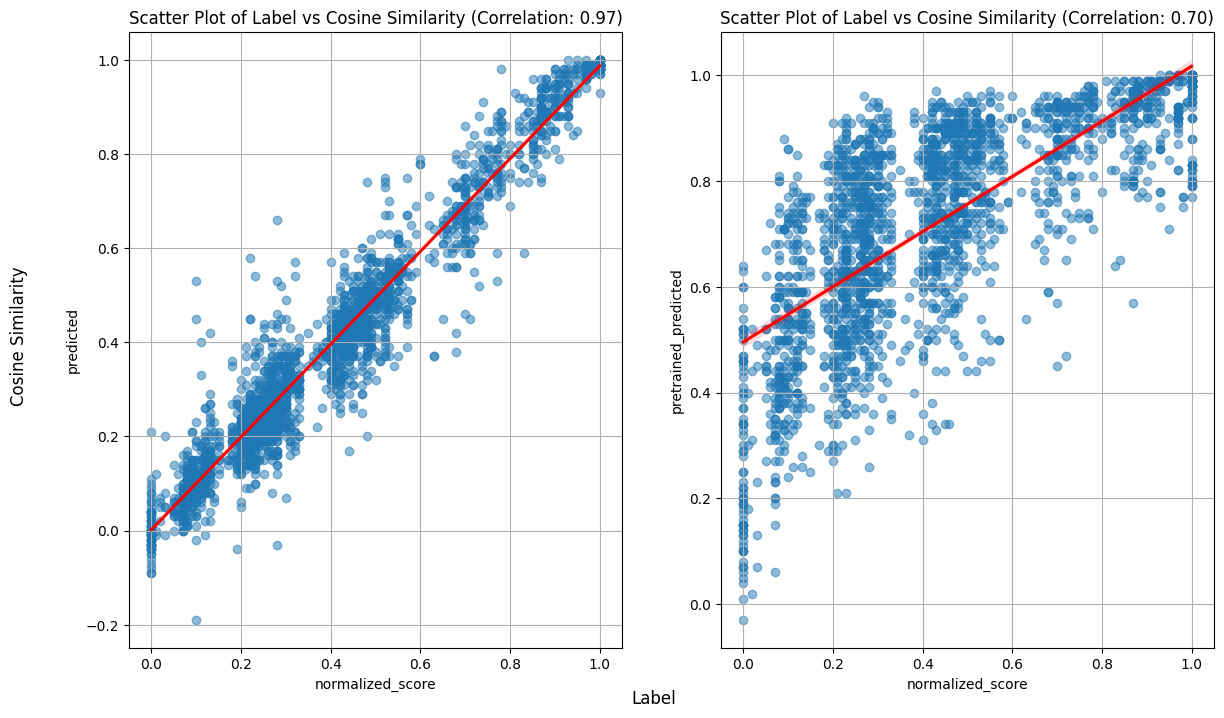

In [30]:
correlation = new_df['normalized_score'].corr(new_df['predicted'])
correlation1 = new_df['normalized_score'].corr(new_df['pretrained_predicted'])

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
sns.regplot(x=new_df['normalized_score'], y=new_df['predicted'], ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={"color": "red"})
axes[0].set_title(f'Scatter Plot of Label vs Cosine Similarity (Correlation: {correlation:.2f})')
axes[0].grid(True)

sns.regplot(x=new_df['normalized_score'], y=new_df['pretrained_predicted'], ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={"color": "red"})
axes[1].set_title(f'Scatter Plot of Label vs Cosine Similarity (Correlation: {correlation1:.2f})')
axes[1].grid(True)

fig.text(0.5, 0.04, 'Label', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Cosine Similarity', va='center', rotation='vertical', fontsize=12)
plt.show()

In [15]:
new_df[new_df['predicted']<0].head()

,reference_answer,answer,score,normalized_score,dataset,dataset_num,predicted
100,1. Bermanfaat untuk pasien kemoterapi Karena k...,Endok Endok Endok Endok,0.0,0.00,analisis_essay,analisis_essay-2,-0.09
302,Gaya hidup hedonis (hedonism) adalah suatu pol...,maaf saya tidak tahu hehehehe,0.0,0.00,analisis_essay,analisis_essay-6,-0.02
356,Borobudur adalah sebuah candi Buddha yang terl...,menjaga hewan dan cagar alam agar tidak punah,1.0,0.01,analisis_essay,analisis_essay-7,-0.01
364,Borobudur adalah sebuah candi Buddha yang terl...,prambanan,0.0,0.00,analisis_essay,analisis_essay-7,-0.05
394,Borobudur adalah sebuah candi Buddha yang terl...,terdiri dari seribu arca,0.0,0.00,analisis_essay,analisis_essay-7,-0.01


In [16]:
new_df['reference_answer'].iloc[0]

'Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada pencernaan, memberikan efek kenyang dengan kandungan selulosa-nya dan penyeimbang asam dan basa dalam tubuh'

# SYNTHETIC DATA

In [10]:
data = {
    "reference_answer" : [
        "Fungsi karbohidrat adalah sebagai pemasok energi, dapat memperlancar proses pada pencernaan, memberikan efek kenyang dengan kandungan selulosa-nya dan penyeimbang asam dan basa dalam tubuh"
    ]*12,
    "answer": [
        "Karbohidrat adalah sumber energi utama tubuh.",
        "Fungsi karbohidrat adalah sebagai sumber energi dan membantu memperlancar pencernaan.",
        "Karbohidrat memberikan energi untuk aktivitas harian serta memperlancar proses pencernaan.",
        "Selain sebagai sumber energi, karbohidrat juga membantu menjaga keseimbangan asam-basa dan memberikan rasa kenyang melalui seratnya.",
        "Karbohidrat berperan sebagai sumber energi, memperlancar pencernaan, memberikan rasa kenyang berkat seratnya, dan menyeimbangkan asam dan basa dalam tubuh.",
        "Karbohidrat menyediakan glukosa yang mendukung metabolisme tubuh dan memastikan proses pencernaan berjalan lancar.",
        "Karbohidrat memberikan tenaga, membantu pencernaan, dan menjaga kestabilan pH tubuh sebagai penyeimbang asam-basa.",
        "Fungsi karbohidrat meliputi penyediaan energi, dukungan pada metabolisme dan pencernaan, serta memberikan rasa kenyang dan menjaga keseimbangan asam-basa.",
        "Sebagai sumber energi utama, karbohidrat membantu pencernaan dan menciptakan rasa kenyang karena kandungan serat, serta berperan dalam menjaga keseimbangan pH tubuh.",
        "Karbohidrat berfungsi ganda: menyediakan energi yang dibutuhkan untuk aktivitas sehari-hari dan mendukung proses pencernaan; selain itu, melalui serat yang terkandung, mereka membantu menciptakan rasa kenyang serta mengatur keseimbangan asam dan basa dalam tubuh.",
        "memberikan nutrisi",
        "untuk nutrisi tubuh"
    ],
    "normalized_score": [
        0.18,
        0.22,
        0.24,
        0.47,
        0.80,
        0.30,
        0.35,
        0.75,
        0.82,
        0.85,
        0.03,
        0.03
    ]
}

new_data = pd.DataFrame(data)
new_data.head()

,reference_answer,answer,normalized_score
0,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat adalah sumber energi utama tubuh.,0.18
1,Fungsi karbohidrat adalah sebagai pemasok ener...,Fungsi karbohidrat adalah sebagai sumber energ...,0.22
2,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat memberikan energi untuk aktivitas ...,0.24
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"Selain sebagai sumber energi, karbohidrat juga...",0.47
4,Fungsi karbohidrat adalah sebagai pemasok ener...,"Karbohidrat berperan sebagai sumber energi, me...",0.80


In [31]:
transformers.utils.logging.set_verbosity_error()
model_name = "indobenchmark/indobert-lite-base-p2"
model_dir = "../experiments/models/best_model/indobert_regression.pt"
pipeline = inference(new_data, model_name, model_dir, RegressionModel)
model_dir2 = "../experiments/models/best_model/indobert_dropout.pt"
pipeline2 = inference(new_data, model_name, model_dir2, RegressionModelDropout, 0.5)
model_dir3 = "../experiments/models/best_model/indobert_multi_lr.pt"
pipeline3 = inference(new_data, model_name, model_dir3, RegressionModel)
model_dir4 = "../experiments/models/best_model/sindobert_regression.pt"
pipeline4 = inference(new_data, model_name, model_dir4, SiameseScoringModel, model_type='sbert')
model_name5 = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
model_dir5 = "../experiments/models/best_model/paraphrase-multilingual-mpnet-base-v2_best_model.pt"
pipeline5 = inference(new_data, model_name5, model_dir5, SiameseModel, model_type='sbert')
pretrained_pipeline = inference(new_data, model_name5, model_dir="", MODEL_CLASS=SiameseModel, model_type='sbert')

In [12]:
INDEX=11

print("BERT Regression :")
label, predicted_score = pipeline.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nBERT Regression Dropout :")
label, predicted_score = pipeline2.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nBERT Regression MultiLR :")
label, predicted_score = pipeline3.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT Regression :")
label, predicted_score = pipeline4.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT Cosine Sim :")
label, predicted_score = pipeline5.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

BERT Regression :
Label Score: 0.03
Predicted Score: 0.08

BERT Regression Dropout :
Label Score: 0.03
Predicted Score: 0.11

BERT Regression MultiLR :
Label Score: 0.03
Predicted Score: 0.13

Sentence-BERT Regression :
Label Score: 0.03
Predicted Score: 0.06

Sentence-BERT Cosine Sim :
Label Score: 0.03
Predicted Score: 0.18


In [32]:
new_data['bert_predicted'] = new_data.apply(lambda x: pipeline.get_prediction(x.name)[1], axis=1)
new_data['bert_do_predicted'] = new_data.apply(lambda x: pipeline2.get_prediction(x.name)[1], axis=1)
new_data['bert_lr_predicted'] = new_data.apply(lambda x: pipeline3.get_prediction(x.name)[1], axis=1)
new_data['sbert_reg_predicted'] = new_data.apply(lambda x: pipeline4.get_prediction(x.name)[1], axis=1)
new_data['sbert_sim_predicted'] = new_data.apply(lambda x: pipeline5.get_prediction(x.name)[1], axis=1)
new_data['pretrained_predicted'] = new_data.apply(lambda x: pretrained_pipeline.get_prediction(x.name)[1], axis=1)

In [36]:
new_data.head()

,reference_answer,answer,normalized_score,bert_predicted,bert_do_predicted,bert_lr_predicted,sbert_reg_predicted,sbert_sim_predicted,pretrained_predicted
0,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat adalah sumber energi utama tubuh.,0.18,0.17,0.19,0.19,0.20,0.20,0.84
1,Fungsi karbohidrat adalah sebagai pemasok ener...,Fungsi karbohidrat adalah sebagai sumber energ...,0.22,0.36,0.40,0.36,0.27,0.60,0.95
2,Fungsi karbohidrat adalah sebagai pemasok ener...,Karbohidrat memberikan energi untuk aktivitas ...,0.24,0.35,0.36,0.35,0.30,0.45,0.90
3,Fungsi karbohidrat adalah sebagai pemasok ener...,"Selain sebagai sumber energi, karbohidrat juga...",0.47,0.41,0.48,0.44,0.34,0.49,0.88
4,Fungsi karbohidrat adalah sebagai pemasok ener...,"Karbohidrat berperan sebagai sumber energi, me...",0.80,0.61,0.64,0.65,0.37,0.81,0.94


In [40]:
results = []

for col in new_data.columns[3:]:
    mse = mean_squared_error(new_data['normalized_score'], new_data[col])
    rmse = np.sqrt(mse)
    pearson_corr, _ = pearsonr(new_data['normalized_score'], new_data[col])
    
    # Append results as a dictionary
    results.append({'Predicted': col, 'MSE': mse, 'RMSE': rmse, 'Pearson Correlation': pearson_corr})

results_df = pd.DataFrame(results).set_index('Predicted')
results_df.head(6)

,MSE,RMSE,Pearson Correlation
Predicted,,,
bert_predicted,0.035958,0.189627,0.869445
bert_do_predicted,0.024067,0.155134,0.898324
bert_lr_predicted,0.029483,0.171707,0.888553
sbert_reg_predicted,0.046667,0.216025,0.879619
sbert_sim_predicted,0.035675,0.188878,0.789731
pretrained_predicted,0.256867,0.506820,0.681462


# NEW DATA

In [3]:
df_sag = pd.read_csv("../data/sag.csv")
# df_sag = df_sag[116:144]
df_sag = df_sag.reset_index(drop=True)
df_sag['normalized_score'] = df_sag['score'] / 5
df_sag.head()

,question,reference_answer,answer,score,normalized_score
0,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,High risk problems are address in the prototyp...,3.5,0.7
1,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,To simulate portions of the desired final prod...,5.0,1.0
2,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,A prototype program simulates the behaviors of...,4.0,0.8
3,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,Defined in the Specification phase a prototype...,5.0,1.0
4,What is the role of a prototype program in pro...,To simulate the behaviour of portions of the d...,It is used to let the users have a first idea ...,3.0,0.6


In [4]:
transformers.utils.logging.set_verbosity_error()
model_name = "indobenchmark/indobert-lite-base-p2"
model_dir = "../experiments/models/best_model/indobert_regression.pt"
pipeline_sag = inference(df_sag, model_name, model_dir, RegressionModel)
pretrained_pipeline_sag = inference(df_sag, model_name, model_dir="", MODEL_CLASS=RegressionModel)
model_dir2 = "../experiments/models/best_model/indobert_dropout.pt"
pipeline_sag2 = inference(df_sag, model_name, model_dir2, RegressionModelDropout, 0.5)
pretrained_pipeline_sag2 = inference(df_sag, model_name, model_dir="", MODEL_CLASS=RegressionModelDropout, dropout=0.5)
model_dir3 = "../experiments/models/best_model/indobert_multi_lr.pt"
pipeline_sag3 = inference(df_sag, model_name, model_dir3, RegressionModel)
model_dir4 = "../experiments/models/best_model/sindobert_regression.pt"
pipeline_sag4 = inference(df_sag, model_name, model_dir4, SiameseScoringModel, model_type='sbert')
model_name5 = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
model_dir5 = "../experiments/models/best_model/paraphrase-multilingual-mpnet-base-v2_best_model.pt"
pipeline_sag5 = inference(df_sag, model_name5, model_dir5, SiameseModel, model_type='sbert')
pretrained_pipeline_sag5 = inference(df_sag, model_name5, model_dir="", MODEL_CLASS=SiameseModel, model_type='sbert')

In [44]:
INDEX=10

print("BERT Regression :")
label, predicted_score = pipeline_sag.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nBERT Regression Dropout :")
label, predicted_score = pipeline_sag2.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nBERT Regression MultiLR :")
label, predicted_score = pipeline_sag3.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT Regression :")
label, predicted_score = pipeline_sag4.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

print("\nSentence-BERT Cosine Sim :")
label, predicted_score = pipeline_sag5.get_prediction(INDEX)
print("Label Score:", label)
print("Predicted Score:", predicted_score)

BERT Regression :
Label Score: 1.0
Predicted Score: 0.54

BERT Regression Dropout :
Label Score: 1.0
Predicted Score: 0.72

BERT Regression MultiLR :
Label Score: 1.0
Predicted Score: 0.73

Sentence-BERT Regression :
Label Score: 1.0
Predicted Score: 0.32

Sentence-BERT Cosine Sim :
Label Score: 1.0
Predicted Score: 0.8


In [5]:
df_sag['bert_predicted'] = df_sag.apply(lambda x: pipeline_sag.get_prediction(x.name)[1], axis=1)
df_sag['bert_do_predicted'] = df_sag.apply(lambda x: pipeline_sag2.get_prediction(x.name)[1], axis=1)
df_sag['bert_lr_predicted'] = df_sag.apply(lambda x: pipeline_sag3.get_prediction(x.name)[1], axis=1)
df_sag['sbert_reg_predicted'] = df_sag.apply(lambda x: pipeline_sag4.get_prediction(x.name)[1], axis=1)
df_sag['sbert_sim_predicted'] = df_sag.apply(lambda x: pipeline_sag5.get_prediction(x.name)[1], axis=1)
df_sag['pre_bert_predicted'] = df_sag.apply(lambda x: pretrained_pipeline_sag.get_prediction(x.name)[1], axis=1)
df_sag['pre_bert_do_predicted'] = df_sag.apply(lambda x: pretrained_pipeline_sag2.get_prediction(x.name)[1], axis=1)
df_sag['pre_sbert_predicted'] = df_sag.apply(lambda x: pretrained_pipeline_sag5.get_prediction(x.name)[1], axis=1)

c:\Users\User\Documents\Code\env\lib\site-packages\transformers\models\albert\modeling_albert.py:404: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attention_output = torch.nn.functional.scaled_dot_product_attention(


In [6]:
results = []

for col in df_sag.columns[5:]:
    mse = mean_squared_error(df_sag['normalized_score'], df_sag[col])
    rmse = np.sqrt(mse)
    pearson_corr, _ = pearsonr(df_sag['normalized_score'], df_sag[col])
    
    # Append results as a dictionary
    results.append({'Predicted': col, 'MSE': mse, 'RMSE': rmse, 'Pearson Correlation': pearson_corr})

results_df = pd.DataFrame(results).set_index('Predicted')
results_df.head(10)

,MSE,RMSE,Pearson Correlation
Predicted,,,
bert_predicted,0.282719,0.531714,0.395008
bert_do_predicted,0.226248,0.475655,0.407388
bert_lr_predicted,0.200898,0.448217,0.421355
sbert_reg_predicted,0.318879,0.564694,0.109409
sbert_sim_predicted,0.153526,0.391825,0.426199
pre_bert_predicted,0.173474,0.416502,0.096116
pre_bert_do_predicted,0.473325,0.687986,0.133561
pre_sbert_predicted,0.120319,0.346871,0.415737


In [2]:
from transformers import AlbertConfig, AlbertModel, AutoModel, AutoConfig

config_model = AlbertConfig.from_pretrained('indobenchmark/indobert-lite-base-p2')
# config_model.embedding_size = 768
# config_model.hidden_size = 512
config_model.intermediate_size = 2048

model = AlbertModel(config_model)
model

AlbertModel(
  (embeddings): AlbertEmbeddings(
    (word_embeddings): Embedding(30000, 128, padding_idx=0)
    (position_embeddings): Embedding(512, 128)
    (token_type_embeddings): Embedding(2, 128)
    (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0, inplace=False)
  )
  (encoder): AlbertTransformer(
    (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
    (albert_layer_groups): ModuleList(
      (0): AlbertLayerGroup(
        (albert_layers): ModuleList(
          (0): AlbertLayer(
            (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (attention): AlbertSdpaAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (attention_dropout): Dropout(p=0, inplace=False)
  

In [18]:
model1 = AutoModel.from_pretrained('indobenchmark/indobert-lite-base-p2')
model1

AlbertModel(
  (embeddings): AlbertEmbeddings(
    (word_embeddings): Embedding(30000, 128, padding_idx=0)
    (position_embeddings): Embedding(512, 128)
    (token_type_embeddings): Embedding(2, 128)
    (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0, inplace=False)
  )
  (encoder): AlbertTransformer(
    (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
    (albert_layer_groups): ModuleList(
      (0): AlbertLayerGroup(
        (albert_layers): ModuleList(
          (0): AlbertLayer(
            (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (attention): AlbertSdpaAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (attention_dropout): Dropout(p=0, inplace=False)
  

In [8]:
import torch
import torch.nn as nn
from transformers import AutoModel
from collections import OrderedDict

class RegressionModel(nn.Module):
    def __init__(self, model_name='indobenchmark/indobert-lite-base-p2', dropout=0.1):
        super().__init__()
        # load pretrained model
        self.model = AutoModel.from_pretrained(model_name)

        self.head_layer = nn.Sequential(OrderedDict([
            ("fc1", nn.Linear(self.model.config.hidden_size, self.model.config.hidden_size)), 
            ("relu1", nn.ReLU()),  # Activation
            ("dropout1", nn.Dropout(p=dropout)),  # Dropout
            ("fc2", nn.Linear(self.model.config.hidden_size, 1))
        ]))

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        score = self.head_layer(cls_embedding)
        return score
    
model = RegressionModel()
model

RegressionModel(
  (model): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertSdpaAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
 